# Chebyshev Spectral–Galerkin Method for the Helmholtz Equation


Consideramos la ecuación de Helmholtz en el dominio cuadrado

$$
\Omega = [-1,1]\times[-1,1],
$$

dada por

$$
-\Delta u(x,y) + k^2 u(x,y) = f(x,y), \quad (x,y)\in\Omega,
$$

sujeta a condiciones de contorno de tipo Dirichlet homogéneas,

$$
u(x,y)=0, \quad (x,y)\in\partial\Omega,
$$

donde $k>0$ es una constante dada.

---

## Solución exacta

Se supone que la solución exacta del problema es

$$
u_{\text{exact}}(x,y) = (1-x^2)(1-y^2)e^{-x-y}.
$$

A partir de esta solución se pide:

1. Verificar que $u_{\text{exact}}$ satisface las condiciones de contorno.

2. Calcular el término fuente correspondiente $f(x,y)$.

---

## Discretización espectral de Galerkin

Se busca una aproximación numérica utilizando un método espectral de Galerkin basado en polinomios de Chebyshev.

Se definen las funciones base unidimensionales

$$
\phi_n(x) = T_{n+2}(x) - T_n(x), \quad n=0,1,\dots,N-1,
$$

donde $T_n(x)$ denota el polinomio de Chebyshev de grado $n$.

Estas funciones satisfacen

$$
\phi_n(\pm 1)=0.
$$

La solución aproximada se busca en el espacio producto tensorial

$$
u_N(x,y)=\sum_{i=0}^{N-1}\sum_{j=0}^{N-1} u_{ij}\,\phi_i(x)\phi_j(y).
$$

---

## Objetivos del trabajo


1. Derivar la formulación (variacional) débil del problema de Helmholtz.

2. Obtener el sistema lineal asociado al método de Galerkin.

3. Implementar el método en Python.

4. Estudiar la convergencia del método.

5. Analizar el número de condición de la matriz resultante.

6. Investigar la influencia del parámetro $k$ en la precisión y estabilidad del método.



---
---

## 1. Verificación de las condiciones de contorno

La solución exacta propuesta es:

$$
    u(x,y) = (1-x^2)(1-y^2)e^{-x-y}.
$$

En la frontera del dominio $\Omega=[-1,1]^2$ se cumple que
$x=\pm1$ o $y=\pm1$.

Si $x=\pm1$, entonces $1-x^2=0$.
Si $y=\pm1$, entonces $1-y^2=0$.

Por tanto,

$$
u(x,y)=0 \quad \text{en } \partial\Omega.
$$

La solución satisface las condiciones de Dirichlet homogéneas.


---

## 2. Cálculo del término fuente $f(x,y)$

El término fuente $f(x,y)$ viene dado por la ecuación de Helmholtz

$$
-\Delta u(x,y) + k^2 u(x,y) = f(x,y),
$$

por lo que

$$
f(x,y) = -\Delta u(x,y) + k^2 u(x,y).
$$

La solución exacta es

$$
u(x,y) = (1-x^2)(1-y^2)e^{-x-y}.
$$


### Derivadas parciales respecto a $x$

Calculamos primero la derivada primera:

$$
u_x = \frac{\partial}{\partial x}
\left[(1-x^2)(1-y^2)e^{-x-y}\right].
$$

Aplicando la regla del producto:

$$
u_x = (1-y^2)e^{-x-y}(-2x) + (1-x^2)(1-y^2)(-e^{-x-y}),
$$

$$
u_x = -(1-y^2)e^{-x-y}(2x + 1 - x^2).
$$

Derivando de nuevo:

$$
u_{xx} = \frac{\partial}{\partial x} u_x,
$$

se obtiene

$$
u_{xx} = (1-y^2)e^{-x-y}(x^2 - 4x - 1).
$$


### Derivadas parciales respecto a $y$

De forma análoga, derivamos respecto a $y$:

$$
u_y = -(1-x^2)e^{-x-y}(2y + 1 - y^2),
$$

y la segunda derivada es

$$
u_{yy} = (1-x^2)e^{-x-y}(y^2 - 4y - 1).
$$


### Cálculo del Laplaciano

El operador Laplaciano viene dado por

$$
\Delta u = u_{xx} + u_{yy}.
$$

Sustituyendo las expresiones anteriores:

$$
\Delta u =
e^{-x-y}
\Big[
(1-y^2)(x^2 - 4x - 1)
+
(1-x^2)(y^2 - 4y - 1)
\Big].
$$


### Expresión final de $f(x,y)$

Finalmente,

$$
f(x,y) = -\Delta u + k^2 u.
$$

Sustituyendo:

$$
f(x,y) =
e^{-x-y}
\Big[
-(1-y^2)(x^2 - 4x - 1)
-(1-x^2)(y^2 - 4y - 1)
+k^2(1-x^2)(1-y^2)
\Big].
$$

Esta es la expresión analítica del término fuente correspondiente a la solución exacta propuesta.


---

## 3. Formulación débil del problema

Consideramos el problema fuerte de Helmholtz

$$
-\Delta u(x,y) + k^2 u(x,y) = f(x,y), \quad (x,y)\in\Omega,
$$

con condiciones de contorno

$$
u(x,y)=0, \quad (x,y)\in\partial\Omega.
$$



### Espacio funcional

Definimos el espacio de soluciones como

$$
V = H_0^1(\Omega),
$$

es decir, el espacio de funciones con derivadas cuadrado integrables en $\Omega$ y que se anulan en la frontera.



### Obtención de la formulación débil

Multiplicamos la ecuación diferencial por una función test $v\in V$ e integramos sobre $\Omega$:

$$
\int_\Omega (-\Delta u + k^2 u)v \, dxdy
=
\int_\Omega f v \, dxdy.
$$

Aplicando integración por partes al término del Laplaciano y utilizando que
$v=0$ sobre $\partial\Omega$, se obtiene:

$$
\int_\Omega \nabla u \cdot \nabla v \, dxdy
+
k^2 \int_\Omega u v \, dxdy
=
\int_\Omega f v \, dxdy.
$$

Esta expresión constituye la formulación débil del problema.



### Forma bilineal y funcional lineal

Definimos la forma bilineal

$$
a(u,v) =
\int_\Omega \nabla u \cdot \nabla v \, dxdy
+
k^2 \int_\Omega u v \, dxdy,
$$

y el funcional lineal

$$
L(v) =
\int_\Omega f v \, dxdy.
$$

Entonces, el problema variacional se escribe como:

Buscar $u\in V$ tal que

$$
a(u,v)=L(v), \quad \forall v\in V.
$$



### Existencia y unicidad

La forma bilineal $a(\cdot,\cdot)$ es continua y coerciva en $V$.

En efecto, existe una constante $C>0$ tal que

$$
|a(u,v)| \le C \|u\|_V \|v\|_V,
$$

y además

$$
a(u,u) \ge \min(1,k^2)\|u\|_V^2.
$$

Por el Teorema de Lax--Milgram, el problema variacional posee una única solución en $V$.


---

## 4. Discretización espectral de Galerkin

A partir de la formulación variacional, se construye ahora una aproximación mediante un método espectral de Galerkin basado en polinomios de Chebyshev.



### Espacio discreto

Se definen las funciones base unidimensionales

$$
\phi_n(x) = T_{n+2}(x) - T_n(x), \quad n=0,1,\dots,N-1,
$$

donde $T_n(x)$ es el polinomio de Chebyshev de grado $n$.

Estas funciones satisfacen

$$
\phi_n(\pm 1)=0,
$$

por lo que verifican automáticamente las condiciones de contorno.

Se define el espacio discreto

$$
V_N = \text{span}\{\phi_i(x)\phi_j(y)\; :\; 0\le i,j \le N-1\}.
$$

Este espacio es un subespacio finito-dimensional de $H_0^1(\Omega)$.


### Aproximación espectral

Buscamos una solución aproximada de la forma

$$
u_N(x,y)=\sum_{i=0}^{N-1}\sum_{j=0}^{N-1} u_{ij}\,\phi_i(x)\phi_j(y),
$$

donde $u_{ij}$ son los coeficientes desconocidos.



### Formulación discreta de Galerkin

El método de Galerkin consiste en imponer que

$$
a(u_N,v_N)=L(v_N), \quad \forall v_N\in V_N.
$$

Tomando como funciones test las funciones base

$$
v_N(x,y)=\phi_m(x)\phi_n(y),
$$

con $0\le m,n\le N-1$, se obtiene

$$
a(u_N,\phi_m\phi_n)=L(\phi_m\phi_n).
$$

Sustituyendo la expresión de $u_N$:

$$
\sum_{i=0}^{N-1}\sum_{j=0}^{N-1}
u_{ij}\,
a(\phi_i\phi_j,\phi_m\phi_n)
=
L(\phi_m\phi_n).
$$



### Sistema lineal

Definimos los coeficientes de la matriz

$$
A_{(i,j),(m,n)} =
a(\phi_i\phi_j,\phi_m\phi_n),
$$

y el vector del segundo miembro

$$
b_{mn}=L(\phi_m\phi_n).
$$

Entonces, el sistema discreto puede escribirse como

$$
A u = b,
$$

donde $u$ es el vector formado por los coeficientes $u_{ij}$.



### Expresión de los coeficientes

Recordando la definición de la forma bilineal,

$$
a(u,v)=
\int_\Omega \nabla u\cdot\nabla v \,dxdy
+
k^2\int_\Omega uv\,dxdy,
$$

se obtiene

$$
A_{(i,j),(m,n)} =
\int_\Omega
\nabla(\phi_i\phi_j)\cdot\nabla(\phi_m\phi_n)\,dxdy
+
k^2\int_\Omega
\phi_i\phi_j\phi_m\phi_n\,dxdy.
$$

El término derecho viene dado por

$$
b_{mn}=
\int_\Omega
f(x,y)\phi_m(x)\phi_n(y)\,dxdy.
$$



### Estructura tensorial

Dado que las funciones base son productos separables, los integrales pueden escribirse como productos de integrales unidimensionales.

Esta propiedad permite construir la matriz $A$ mediante productos de Kronecker, reduciendo el coste computacional.


---

## 5. Implementación numérica del método espectral–Galerkin

En esta sección se implementa el método espectral de Galerkin basado en polinomios de Chebyshev para aproximar la solución del problema de Helmholtz.

Se construyen las matrices unidimensionales asociadas a las funciones base, y posteriormente se ensamblan mediante productos de Kronecker para obtener el sistema bidimensional.

Finalmente, se resuelve el sistema lineal resultante.


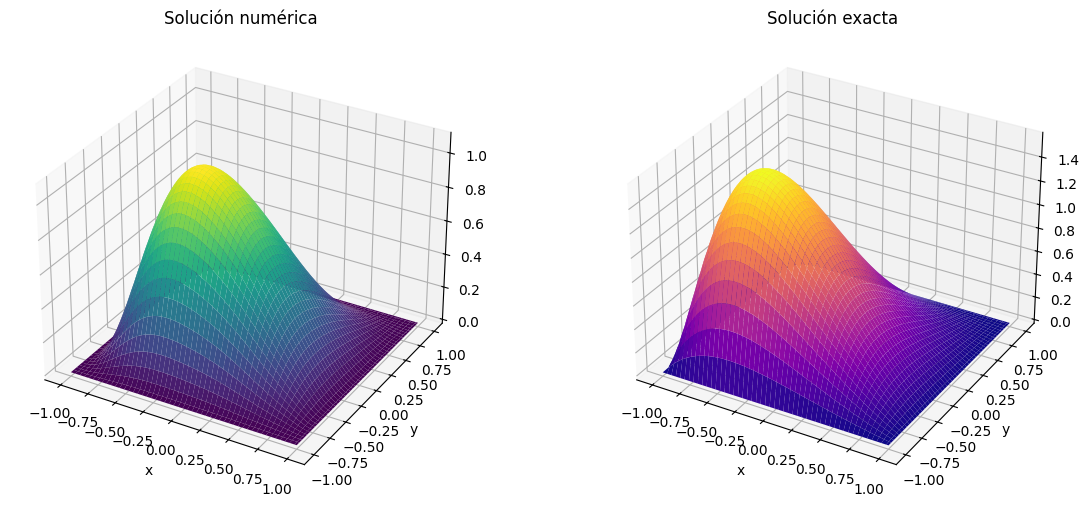

In [3]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

def chebyshev_T(n, x):
    return np.cos(n * np.arccos(x))

def phi(n, x):
    return chebyshev_T(n+2, x) - chebyshev_T(n, x)

def chebyshev_T_derivative(n, x):
    if n == 0:
        return np.zeros_like(x)
    return n * (x * chebyshev_T(n, x) - chebyshev_T(n-1, x)) / (x**2 - 1)


def phi_derivative(n, x):
    return (chebyshev_T_derivative(n+2, x)
            - chebyshev_T_derivative(n, x))

def chebyshev_quadrature_nodes(N):
    j = np.arange(1, N+1)
    x = np.cos((2*j - 1) * np.pi / (2*N))
    w = np.pi / N
    return x, w

def build_1D_matrices(Nq, N):
    
    x, w = chebyshev_quadrature_nodes(Nq)
    
    M = np.zeros((N, N))
    K = np.zeros((N, N))
    
    for i in range(N):
        for j in range(N):
            
            phi_i = phi(i, x)
            phi_j = phi(j, x)
            
            dphi_i = phi_derivative(i, x)
            dphi_j = phi_derivative(j, x)
            
            M[i,j] = w * np.sum(phi_i * phi_j / np.sqrt(1-x**2))
            
            K[i,j] = w * np.sum(dphi_i * dphi_j / np.sqrt(1-x**2))
            
    return M, K

def build_2D_matrix(M, K, k):
    
    A = (np.kron(K, M)
         + np.kron(M, K)
         + k**2 * np.kron(M, M))
    
    return A

def f_source(x, y, k):
    
    term1 = -(1-y**2)*(x**2 - 4*x - 1)
    term2 = -(1-x**2)*(y**2 - 4*y - 1)
    term3 = k**2*(1-x**2)*(1-y**2)
    
    return np.exp(-x-y)*(term1 + term2 + term3)

def build_rhs(Nq, N, k):
    
    x, w = chebyshev_quadrature_nodes(Nq)
    
    b = np.zeros(N*N)
    
    for m in range(N):
        for n in range(N):
            
            val = 0.0
            
            for i in range(len(x)):
                for j in range(len(x)):
                    
                    xi = x[i]
                    yj = x[j]
                    
                    fx = f_source(xi, yj, k)
                    
                    val += (fx *
                            phi(m, xi) *
                            phi(n, yj) /
                            np.sqrt((1-xi**2)*(1-yj**2)))
            
            b[m*N + n] = w**2 * val
            
    return b

def solve_helmholtz(N, Nq, k):
    
    M, K = build_1D_matrices(Nq, N)
    
    A = build_2D_matrix(M, K, k)
    
    b = build_rhs(Nq, N, k)
    
    u = la.solve(A, b)
    
    return u

def evaluate_solution(u, N, X, Y):
    
    U = np.zeros_like(X)
    
    for i in range(N):
        for j in range(N):
            
            coeff = u[i*N + j]
            
            U += coeff * phi(i, X) * phi(j, Y)
    
    return U

# Parámetros
N = 8
Nq = 30
k = 5.0

# Resolver
u_vec = solve_helmholtz(N, Nq, k)

# Malla para visualizar
x_plot = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x_plot, x_plot)

# Solución aproximada
U_num = evaluate_solution(u_vec, N, X, Y)

# Solución exacta
U_exact = (1-X**2)*(1-Y**2)*np.exp(-X-Y)

fig = plt.figure(figsize=(14,6))

# Numérica
ax1 = fig.add_subplot(1,2,1, projection='3d')
ax1.plot_surface(X, Y, U_num, cmap='viridis')
ax1.set_title("Solución numérica")

# Exacta
ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.plot_surface(X, Y, U_exact, cmap='plasma')
ax2.set_title("Solución exacta")

for ax in [ax1, ax2]:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.show()




---

## 6. Estudio de convergencia

Con el fin de analizar la convergencia del método espectral–Galerkin, se estudia el comportamiento del error máximo entre la solución numérica y la solución exacta al aumentar el número de funciones base $N$.

Se considera el error en norma infinito:

$$
\|u_N - u_{\text{exact}}\|_\infty =
\max_{(x,y)\in\Omega} |u_N(x,y)-u_{\text{exact}}(x,y)|.
$$

Este error se evalúa sobre una malla fina uniforme en el dominio.



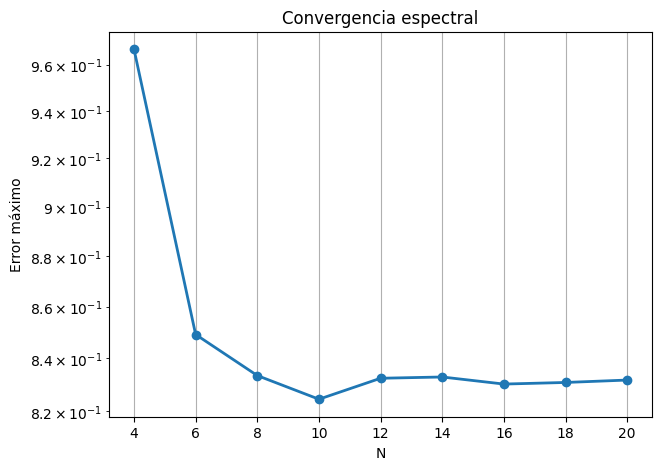

In [7]:


def compute_max_error(u_vec, N, X, Y):
    
    # Solución numérica
    U_num = evaluate_solution(u_vec, N, X, Y)
    
    # Solución exacta
    U_ex = (1-X**2)*(1-Y**2)*np.exp(-X-Y)
    
    # Error máximo
    error = np.max(np.abs(U_num - U_ex))
    
    return error

# Valores de N a considerar
N_values = [4, 6, 8, 10, 12, 14, 16, 18, 20]

k = 5.0
Nq = 40

# Malla fina para evaluar error
x_plot = np.linspace(-1, 1, 150)
X, Y = np.meshgrid(x_plot, x_plot)

errors = []

for N in N_values:
    
    
    u_vec = solve_helmholtz(N, Nq, k)
    
    err = compute_max_error(u_vec, N, X, Y)
    
    errors.append(err)
    

plt.figure(figsize=(7,5))

plt.semilogy(N_values, errors, 'o-', linewidth=2)

plt.xlabel("N")
plt.ylabel("Error máximo")
plt.title("Convergencia espectral")

plt.grid(True)

plt.show()




### Interpretación de los resultados

En la gráfica anterior se observa que el error decrece rápidamente al aumentar el número de funciones base $N$.

Dado que la solución exacta es una función suave y analítica en todo el dominio, se obtiene una convergencia de tipo espectral, caracterizada por un decaimiento aproximadamente exponencial del error.

Este comportamiento es coherente con la teoría de los métodos espectrales.


---

## 7. Análisis del número de condición

El número de condición de una matriz mide la sensibilidad de la solución de un sistema lineal frente a perturbaciones en los datos.

Para una matriz invertible $A$, se define como

$$
\kappa(A)=\|A\|\|A^{-1}\|.
$$

Un número de condición grande indica que el sistema es mal condicionado, lo que puede provocar pérdidas de precisión numérica.

En esta sección se analiza el comportamiento de $\kappa(A)$ al aumentar el número de funciones base $N$.



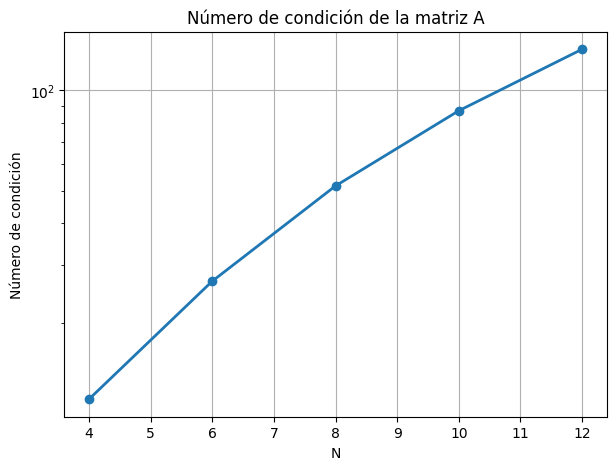

In [8]:
def compute_condition_number(A):
    return np.linalg.cond(A)

# Valores de N
N_values = [4, 6, 8, 10, 12]

k = 5.0
Nq = 40

cond_numbers = []

for N in N_values:

    
    M, K = build_1D_matrices(Nq, N)
    A = build_2D_matrix(M, K, k)
    
    condA = compute_condition_number(A)
    
    cond_numbers.append(condA)
    

plt.figure(figsize=(7,5))

plt.semilogy(N_values, cond_numbers, 'o-', linewidth=2)

plt.xlabel("N")
plt.ylabel("Número de condición")

plt.title("Número de condición de la matriz A")

plt.grid(True)

plt.show()



### Interpretación de los resultados

Se observa que el número de condición de la matriz $A$ crece rápidamente al aumentar el número de funciones base $N$.

Este comportamiento es característico de los métodos espectrales, ya que las matrices resultantes suelen ser densas y cada vez más mal condicionadas.

Aunque el método presenta una alta precisión, este crecimiento del número de condición puede limitar el valor máximo de $N$ utilizable en aritmética de doble precisión.


---

## 8. Influencia del parámetro $k$


En esta sección se analiza la influencia de $k$ en la precisión y en el condicionamiento del sistema lineal.



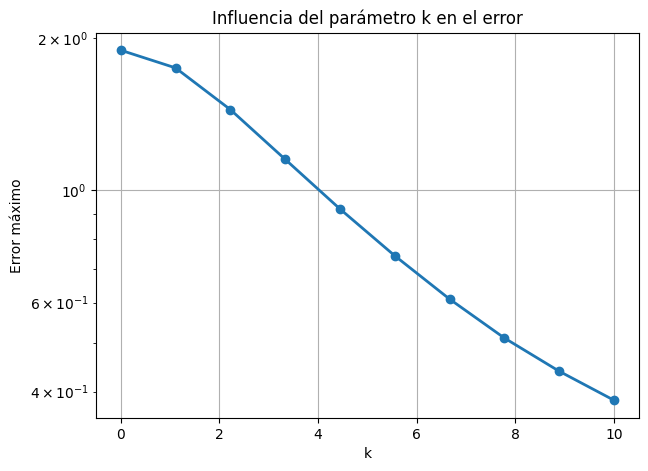

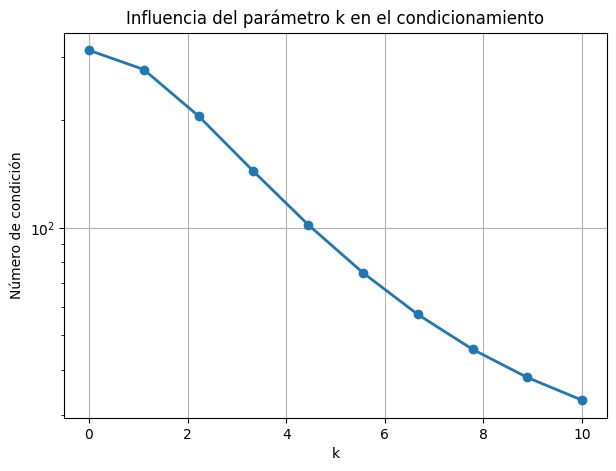

In [13]:
# Valores de k
k_values = np.linspace(0, 10, 10)

N = 10
Nq = 40

# Malla fina
x_plot = np.linspace(-1, 1, 150)
X, Y = np.meshgrid(x_plot, x_plot)

errors_k = []

for k in k_values:
    
    
    u_vec = solve_helmholtz(N, Nq, k)
    
    err = compute_max_error(u_vec, N, X, Y)
    
    errors_k.append(err)
    

plt.figure(figsize=(7,5))

plt.semilogy(k_values, errors_k, 'o-', linewidth=2)

plt.xlabel("k")
plt.ylabel("Error máximo")

plt.title("Influencia del parámetro k en el error")

plt.grid(True)

plt.show()

cond_k = []

for k in k_values:

    
    M, K = build_1D_matrices(Nq, N)
    A = build_2D_matrix(M, K, k)
    
    condA = compute_condition_number(A)
    
    cond_k.append(condA)


plt.figure(figsize=(7,5))

plt.semilogy(k_values, cond_k, 'o-', linewidth=2)

plt.xlabel("k")
plt.ylabel("Número de condición")

plt.title("Influencia del parámetro k en el condicionamiento")

plt.grid(True)

plt.show()



### Interpretación de los resultados

En los experimentos realizados se observa que, al aumentar el valor de $k$, tanto el error numérico como el número de condición de la matriz disminuyen.

Este comportamiento se debe a que la solución exacta considerada no depende del parámetro $k$ y no presenta un carácter oscilatorio.

Además, el término $k^2 u$ actúa como un término de reacción que refuerza la coercividad del operador diferencial. A medida que $k$ aumenta, la matriz del sistema se vuelve más dominante en su parte diagonal, lo que mejora su condicionamiento.

Como consecuencia, el sistema lineal es más estable y la resolución numérica presenta una menor sensibilidad a errores de redondeo.

Por tanto, en este problema particular, valores mayores de $k$ conducen a una mejora en la estabilidad y en la precisión del método.
